In [1]:
import torch # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2, os, json, gc, math
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils.Plotter.index import Plotter
from Network.index import ModelNetwork
from utils.index import *

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU
pd.set_option('display.max_columns', None)

2.7.1+cu118
True
Quadro P6000


# HISTÓRICO DE TREINAMENTO

In [3]:
df = []

for bakup in os.listdir('Backup/'):
    path = f'Backup/{bakup}/info.json'

    with open(path, 'r', encoding='utf-8') as file:
        file = json.loads(file.read())

    info = {}
    for key, value in file.items():
        info.update(value)

    if not info.get('dataset'):
        info['dataset'] = 'dataset0'

    info['id'] = int(info.get('path').split('_')[-1])
    df.append(info)


df = pd.DataFrame(df).sort_values(by='id')
df.head()

,path,loss,scheduler,epochs,batch_size,val_iou,test_iou,network,dataset,img_size,lr,dropout,num_filters,n_images,classes,channels,mean,id
6,model_1,dice_focal,plateau,100,2,0.796070,0.778363,unet3d_v2,dataset_wu,"[128, 128, 128]",0.0010,0.1,32,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.778363,1
13,model_2,dice_focal,plateau,100,2,0.790710,0.767553,unet3d_v2,dataset_wu,"[128, 128, 128]",0.0005,0.1,32,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.767553,2
11,model_3,dice_focal,plateau,100,2,0.793335,0.773646,unet3d_v2,dataset_wu,"[128, 128, 128]",0.0050,0.1,32,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.773646,3
12,model_4,dice_focal,plateau,100,2,0.779384,0.753020,unet3d_v2,dataset_wu,"[128, 128, 128]",0.0001,0.1,32,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.753020,4
5,model_5,dice_focal,plateau,100,2,0.799283,0.776522,unet3d_v2,dataset_wu,"[128, 128, 128]",0.0100,0.1,32,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.776522,5


# ANÁLISE DE VARIAÇÕES

target: loss | fixed: {'network': 'unet3d_v2', 'lr': 0.001, 'num_filters': 32, 'dropout': 0.1, 'img_size': '[128, 128, 128]'}


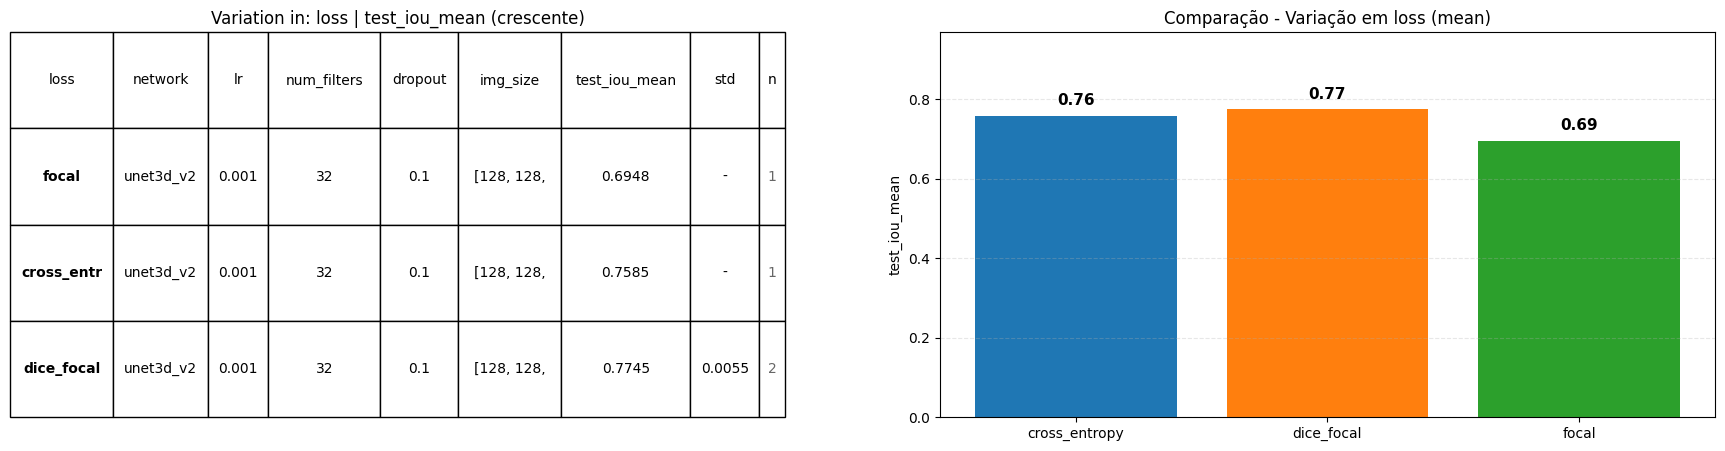

target: network | fixed: {'loss': 'dice_focal', 'lr': 0.001, 'num_filters': 32, 'dropout': 0.1, 'img_size': '[128, 128, 128]'}


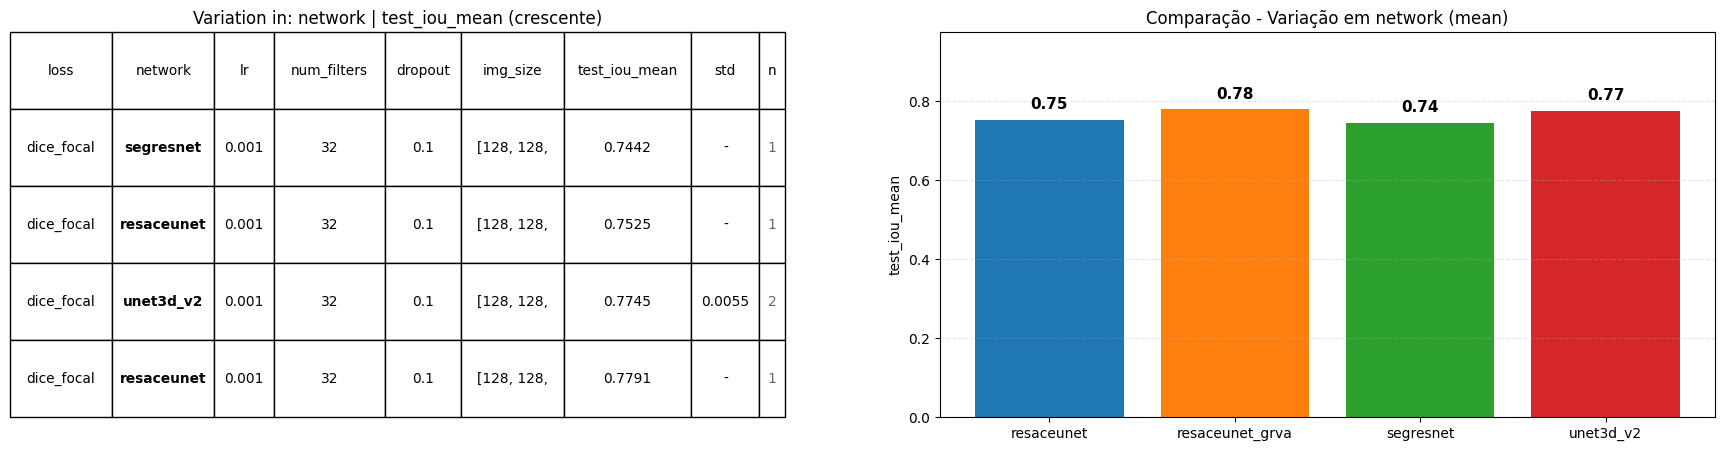

target: network | fixed: {'loss': 'smooth_dice', 'lr': 0.0001, 'num_filters': 32, 'dropout': 0.0, 'img_size': '[128, 128, 128]'}


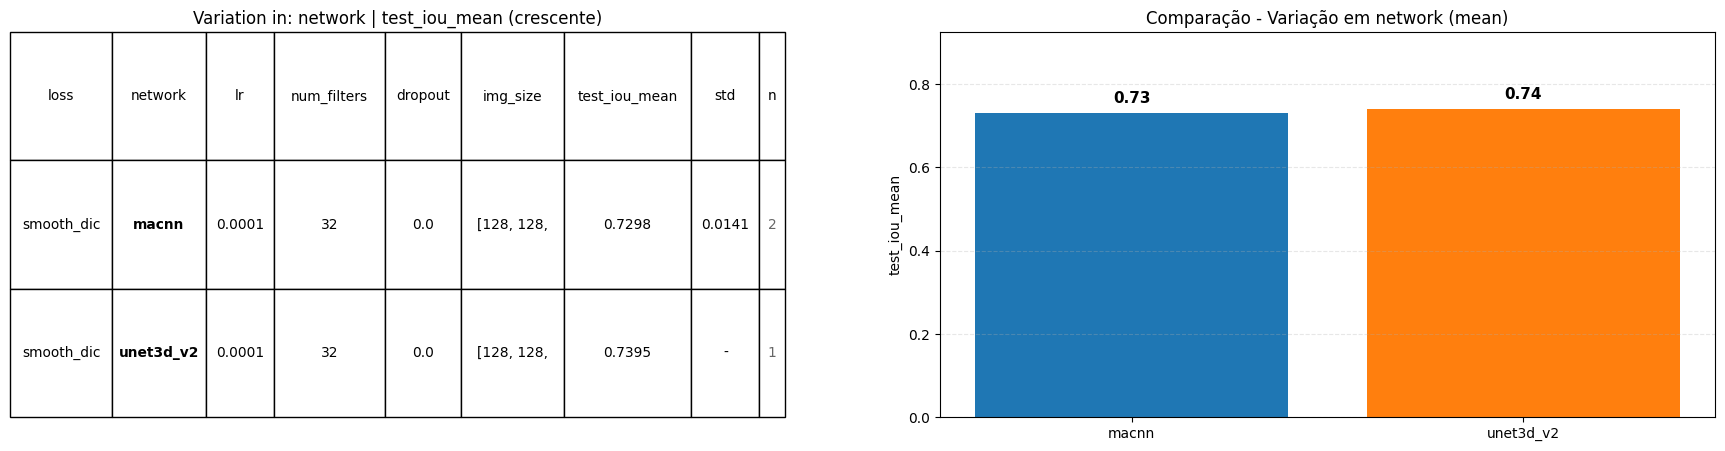

target: lr | fixed: {'loss': 'dice_focal', 'network': 'unet3d_v2', 'num_filters': 32, 'dropout': 0.1, 'img_size': '[128, 128, 128]'}


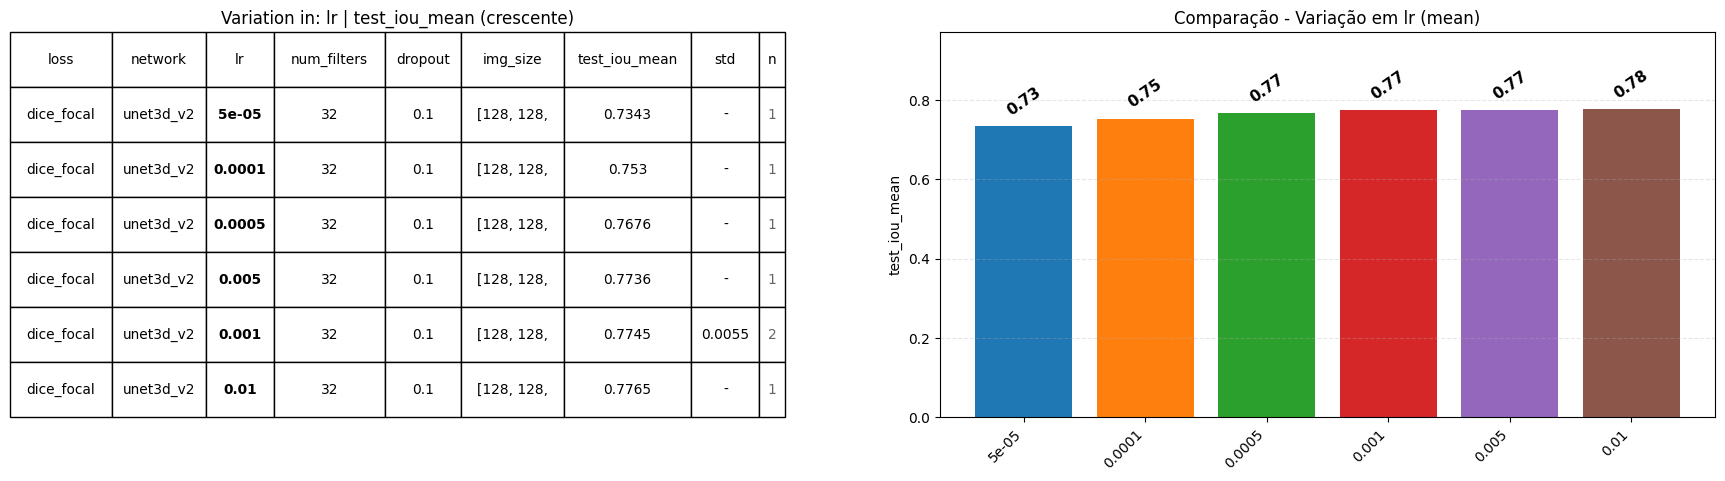

target: dropout | fixed: {'loss': 'dice_focal', 'network': 'unet3d_v2', 'lr': 0.001, 'num_filters': 32, 'img_size': '[128, 128, 128]'}


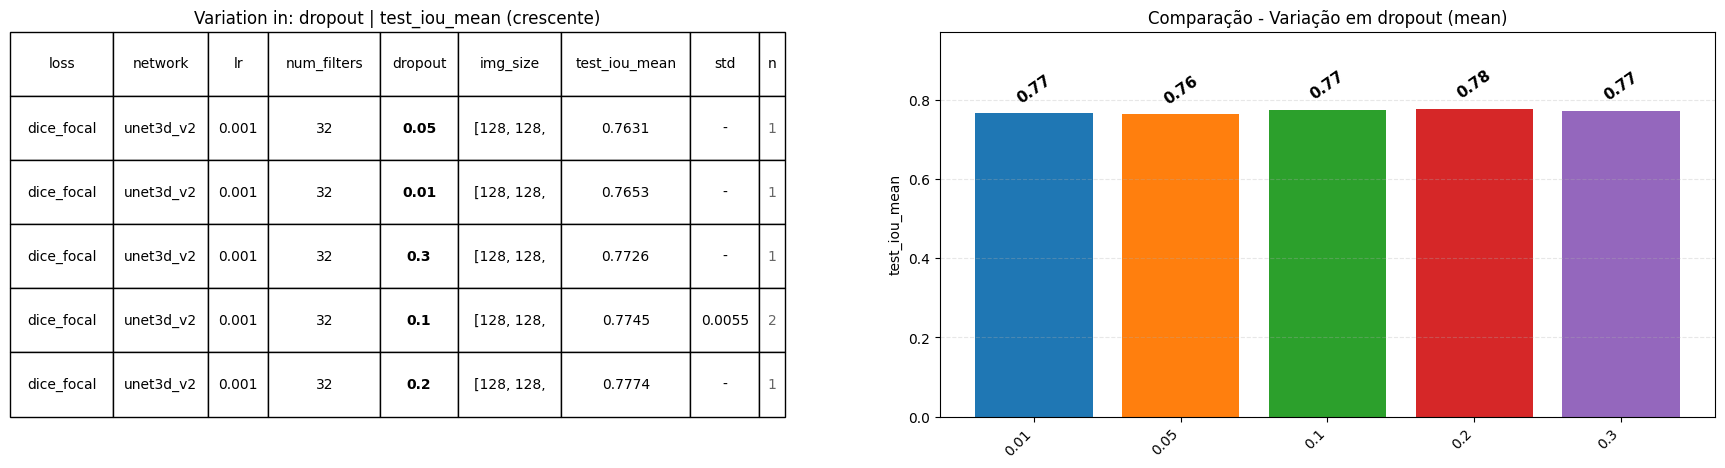

target: img_size | fixed: {'loss': 'dice_focal', 'network': 'unet3d_v2', 'lr': 0.001, 'num_filters': 32, 'dropout': 0.1}


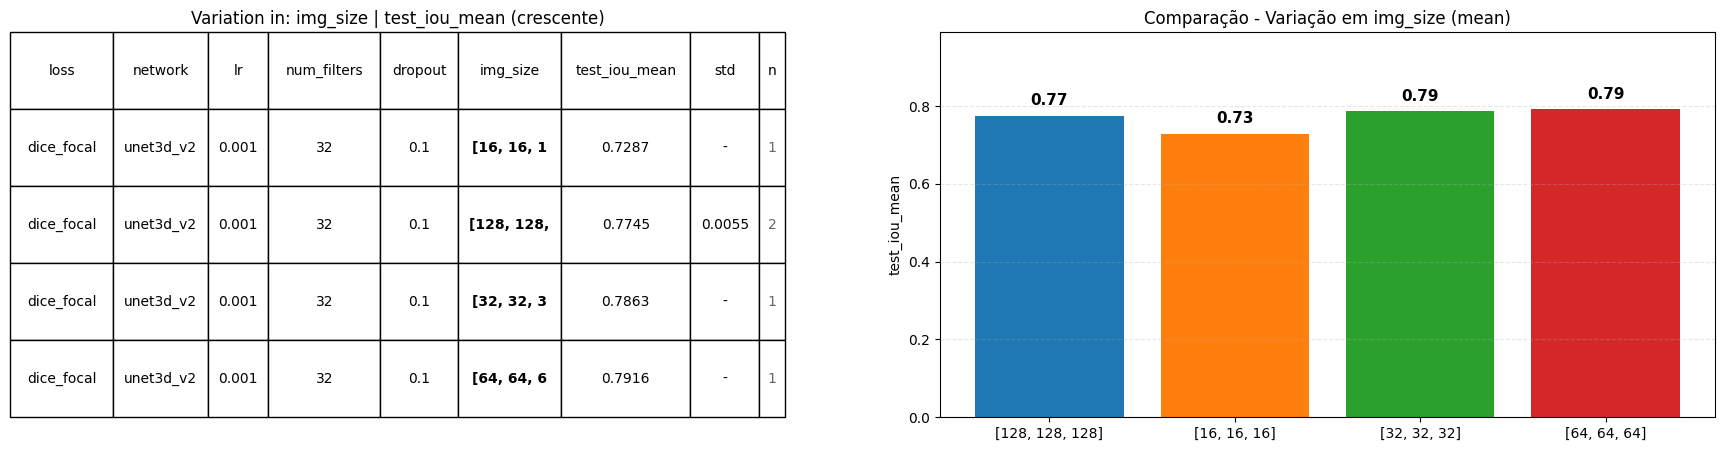

In [4]:
class VariationAnalysis:
    MODES = ('min', 'max', 'mean', 'median')
    COUNT = 'n'

    def __init__(self, df, variations, id=None, metric='test_mre_mm', mode='mean', asc=True):
        self.df = df.copy()
        self.variations = [v for v in variations if v in self.df.columns]
        self.id = id if id in self.df.columns else None
        self.metric = metric
        self.mode   = mode
        self.asc = asc
        self.max_str_len      = 10
        self.min_runs_for_std = 3
        self.metric_label = f'{metric}_{mode}'
        self._prepare()

    def _prepare(self):
        self.df[self.metric] = pd.to_numeric(self.df[self.metric], errors='coerce')
        self.df = self.df.dropna(subset=[self.metric])

        for col in self.variations:
            numeric = pd.to_numeric(self.df[col], errors='coerce')
            is_numeric = numeric.notna().sum() == self.df[col].notna().sum()
            self.df[col] = numeric if is_numeric else self.df[col].astype(str)

        if self.id:
            self.df[self.id] = self.df[self.id].astype(str)

    def _slices(self):
        for var in self.variations:
            fixed = [c for c in self.variations if c != var]
            groups = self.df.groupby(fixed, dropna=False) if fixed else [(None, self.df)]

            for _, group in groups:
                if group[var].nunique(dropna=False) <= 1:
                    continue
                fixed_values = group.iloc[0][fixed].to_dict() if fixed else {}
                yield var, fixed_values, group

    def _aggregate(self, group, var):
        gb = group.groupby(var, dropna=False)[self.metric]
        agg = gb.agg([self.mode, 'std', 'size']).rename(columns={self.mode: self.metric_label, 'size': self.COUNT}).reset_index()

        if self.id and self.mode in ('min', 'max'):
            idx = gb.idxmin() if self.mode == 'min' else gb.idxmax()
            agg[self.id] = group.loc[idx.values, self.id].values
            
        return agg[agg[self.metric_label].notna()]

    def _build_table(self, agg, fixed_values):
        table = agg.sort_values(self.metric_label, ascending=self.asc, kind='stable').copy()
        table[self.metric_label] = table[self.metric_label].round(4)
        
        if 'std' in table.columns:
            table['std'] = table['std'].round(4)

        for col, value in fixed_values.items():
            table[col] = value

        cols = [c for c in self.variations if c in table.columns]
        if self.id in table.columns:
            cols.append(self.id)
            
        show_cols = cols + [self.metric_label]
        if 'std' in table.columns:
            show_cols.append('std')
        show_cols.append(self.COUNT)
            
        return table[show_cols]

    def _format(self, table):
        show = table.copy()
        
        if 'std' in show.columns:
            show['std'] = show['std'].apply(lambda x: f'{x:.4f}' if pd.notna(x) else '-')
            
        show = show.astype(str)
        if self.id in show.columns:
            show[self.id] = show[self.id].map(os.path.basename)

        for col in show.columns:
            if col != self.COUNT and col != 'std':
                show[col] = show[col].str.slice(0, self.max_str_len)
        return show

    def _char_widths(self, show):
        widths = []
        for col in show.columns:
            content = int(show[col].str.len().max())
            padding = 2
            widths.append(max(len(str(col)), content) + padding)
        return widths

    def _fontsize(self, ax, char_widths, rows):
        fig_w, fig_h = ax.figure.get_size_inches()
        pos = ax.get_position()
        fit_w = fig_w * pos.width * 72 / (sum(char_widths) * 0.62)
        fit_h = fig_h * pos.height * 72 / (rows + 1) * 0.55
        return max(6, min(14, fit_w, fit_h))

    def _style(self, tbl, show, bold_col):
        highlight = {}
        if bold_col in show.columns:
            highlight[show.columns.get_loc(bold_col)] = dict(fontweight='bold')
        if self.COUNT in show.columns:
            highlight[show.columns.get_loc(self.COUNT)] = dict(color='0.4')
        for (row, col), cell in tbl.get_celld().items():
            if row > 0 and col in highlight:
                cell.set_text_props(**highlight[col])

    def _draw_table(self, ax, table, title, bold_col=None):
        ax.axis('off')
        show = self._format(table)
        char_widths = self._char_widths(show)
        total = sum(char_widths)

        tbl = ax.table(cellText=show.values, colLabels=show.columns, colWidths=[w / total for w in char_widths], loc='center', cellLoc='center', bbox=[0, 0, 1, 1])
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(self._fontsize(ax, char_widths, len(show)))

        self._style(tbl, show, bold_col)
        ax.set_title(title)

    def _draw_chart(self, agg, var):
        chart = agg.sort_values(var, kind='stable')
        labels = chart[var].astype(str).tolist()
        values = chart[self.metric_label].tolist()
        counts = chart[self.COUNT].tolist()
        stds   = chart['std'].tolist() if 'std' in chart.columns else [float('nan')]*len(values)
        rotation = 30 if len(labels) > 4 else 0

        vmin, vmax = min(values), max(values)
        top = vmax * 1.25 if vmax > 0 else vmax + abs(vmax) * 0.25 + 1e-6
        bottom = min(0.0, vmin * 1.25)
        title  = f'Comparação - Variação em {var} ({self.mode})'

        metrics_dict = dict(zip(labels, values))
        valid_stds   = [std if (count >= self.min_runs_for_std and pd.notna(std)) else float('nan') for count, std in zip(counts, stds)]

        try:
            Plotter(metrics_dict, limits=(bottom, top), title=title, stds=valid_stds)
        except NameError:
            bars = plt.bar(labels, values)
            for bar, std in zip(bars, valid_stds):
                yval = bar.get_height()
                if pd.notna(std):
                    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f} ± {std:.2f}', va='bottom', ha='center', rotation=rotation)
                else:
                    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom', ha='center')
            plt.ylim(bottom, top * 1.2)
            plt.xticks(rotation=rotation)
            plt.title(title)
        
        plt.ylabel(self.metric_label)

    def plot(self):
        order = 'crescente' if self.asc else 'decrescente'

        for var, fixed_values, group in self._slices():
            print(f'target: {var} | fixed: {fixed_values}')

            agg = self._aggregate(group, var)
            if agg.empty:
                continue

            table  = self._build_table(agg, fixed_values)
            height = max(5, min(20, len(table) * 0.5 + 2))
            fig = plt.figure(figsize=(22, height))
            ax  = fig.add_subplot(1, 2, 1)
            self._draw_table(ax, table, f'Variation in: {var} | {self.metric_label} ({order})', bold_col=var)

            fig.add_subplot(1, 2, 2)
            self._draw_chart(agg, var)
            plt.show()


variations = ['loss', 'network', 'lr', 'num_filters', 'dropout', 'img_size']
analysis = VariationAnalysis(df, variations, id='path', metric='test_iou', mode='mean', asc=True)
analysis.plot()